# 🚀 Datathon 2026 — ML Revenue Forecasting Pipeline

**Goal:** Predict daily Revenue & COGS for 2023-01-01 → 2024-07-01

**Best Model:** XGBoost V6 + V2 Ensemble (50/50 blend)  
**Best Kaggle Score:** submission_v6_blend5.csv

---
## Pipeline Overview
1. Load & merge data (test1.csv + sales.csv)
2. Growth analysis (YoY trends)
3. Feature engineering (58 features)
4. XGBoost training with early stopping
5. Walk-forward forecast (2023–2024)
6. Ensemble blending 


In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Đường dẫn data — điều chỉnh nếu cần
import os
# Auto-detect data path whether running in VSCode root or notebook folder
if os.path.exists('../data'):
    DATA_DIR = '../data'
elif os.path.exists('github_submission/data'):
    DATA_DIR = 'github_submission/data'
elif os.path.exists('data'):
    DATA_DIR = 'data'
else:
    DATA_DIR = '/Users/huynhledinhtrung/Downloads/datathon-2026-round-1/github_submission/data'
  
print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Load & Merge Data


In [2]:
# Đọc feature_matrix.csv (feature matrix đã engineered sẵn)
feature_matrix = pd.read_csv(f'{DATA_DIR}/feature_matrix.csv')
feature_matrix['Date'] = pd.to_datetime(feature_matrix['Date'], dayfirst=True)
feature_matrix = feature_matrix.sort_values('Date').reset_index(drop=True)

# Đọc sales.csv (Revenue + COGS thực tế)
sales = pd.read_csv(f'{DATA_DIR}/sales.csv', parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
sales['COGS_ratio'] = sales['COGS'] / sales['Revenue']

# Merge
df = pd.merge(feature_matrix, sales[['Date', 'COGS', 'COGS_ratio']], on='Date', how='left')
df['year']        = df['Date'].dt.year
df['month']       = df['Date'].dt.month
df['weekday_num'] = df['Date'].dt.weekday

print(f"Data range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Total rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
df.head()


Data range: 2013-01-01 → 2022-12-31
Total rows: 3,804
Columns: 33


,Date,Revenue,year,month,weekday,quarter,day_of_month,Revenue_lag_1,Revenue_lag_7,Revenue_lag_14,...,total_orders_lag_1,cancelled_share_lag_1,delivered_share_lag_1,inventory_month_key,fill_rate_prev_month,stockout_share_prev_month,potential_revenue_lost_prev_month,COGS,COGS_ratio,weekday_num
0,2013-01-01,5304546.99,2013.0,1.0,Tuesday,1.0,1.0,0.00,0.0,0.0,...,341.0,0.096774,0.797654,2012-12,0.950556,0.703786,645832.5207,4156070.20,0.783492,1.0
1,2013-01-02,1606940.44,2013.0,1.0,Wednesday,1.0,2.0,5304546.99,0.0,0.0,...,288.0,0.093750,0.781250,2012-12,0.950556,0.703786,645832.5207,1237497.84,0.770096,2.0
2,2013-01-03,2281680.01,2013.0,1.0,Thursday,1.0,3.0,1606940.44,0.0,0.0,...,47.0,0.085106,0.872340,2012-12,0.950556,0.703786,645832.5207,1832133.02,0.802975,3.0
3,2013-01-04,2376895.46,2013.0,1.0,Friday,1.0,4.0,2281680.01,0.0,0.0,...,81.0,0.098765,0.814815,2012-12,0.950556,0.703786,645832.5207,1940747.07,0.816505,4.0
4,2013-01-05,2509462.77,2013.0,1.0,Saturday,1.0,5.0,2376895.46,0.0,0.0,...,83.0,0.180723,0.722892,2012-12,0.950556,0.703786,645832.5207,1977027.71,0.787829,5.0


## 2. YoY Growth Analysis


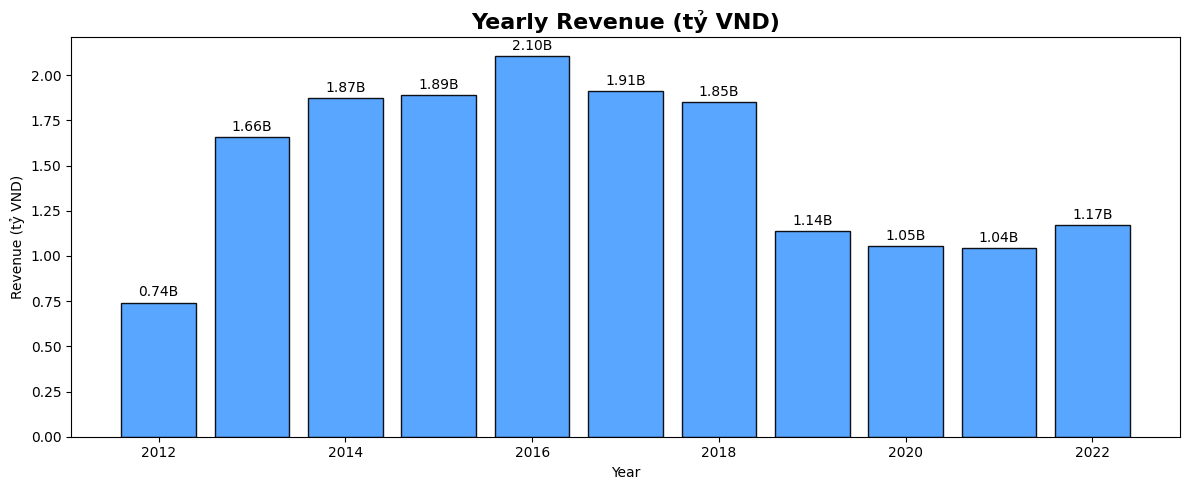

YoY 2020→2021: 0.9891
YoY 2021→2022: 1.1215
Weighted growth for 2023: 1.0685


In [3]:
sales['year'] = sales['Date'].dt.year
yearly_rev = sales.groupby('year')['Revenue'].sum()

# Visualize
fig, ax = plt.subplots(figsize=(12, 5))
yearly_rev_b = yearly_rev / 1e9
bars = ax.bar(yearly_rev_b.index, yearly_rev_b.values, color='#58A6FF', edgecolor='#0D1117')
ax.set_title('Yearly Revenue (tỷ VND)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Revenue (tỷ VND)')
for bar, val in zip(bars, yearly_rev_b.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}B',
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# YoY growth
growth_2122 = yearly_rev[2022] / yearly_rev[2021]
growth_2021 = yearly_rev[2021] / yearly_rev[2020]
weighted_growth = 0.6 * growth_2122 + 0.4 * growth_2021
print(f"YoY 2020→2021: {growth_2021:.4f}")
print(f"YoY 2021→2022: {growth_2122:.4f}")
print(f"Weighted growth for 2023: {weighted_growth:.4f}")


## 3. Feature Engineering (58 features)

**Categories:**
- **Temporal:** year, month, weekday, cyclical sin/cos, trend index, flags
- **Revenue lags:** lag-1, 7, 14, 28, 364, 365, 366 + rolling mean/std
- **Same-week-last-year:** avg of lag-362→369
- **Traffic:** sessions, pageviews, bounce rate
- **Business:** promo share, discount amount, order count
- **Inventory:** fill rate, stockout share, revenue lost


In [4]:
# ── Lag features ──
for lag in [1, 7, 14, 28, 364, 365, 366]:
    df[f'Rev_lag_{lag}'] = df['Revenue'].shift(lag)

df['Rev_same_week_ly'] = sum(df['Revenue'].shift(d) for d in range(362, 370)) / 8

# ── Rolling stats (shift-1 to avoid leakage) ──
df['roll7_mean']     = df['Revenue'].shift(1).rolling(7).mean()
df['roll28_mean']    = df['Revenue'].shift(1).rolling(28).mean()
df['roll7_std']      = df['Revenue'].shift(1).rolling(7).std()
df['roll28_std']     = df['Revenue'].shift(1).rolling(28).std()
df['roll7_mean_ly']  = df['roll7_mean'].shift(365)
df['roll28_mean_ly'] = df['roll28_mean'].shift(365)

# ── Cyclical time ──
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['wday_sin']  = np.sin(2 * np.pi * df['weekday_num'] / 7)
df['wday_cos']  = np.cos(2 * np.pi * df['weekday_num'] / 7)

# ── Flag features ──
df['is_weekend']     = (df['weekday_num'] >= 5).astype(int)
df['is_month_start'] = (df['day_of_month'] <= 5).astype(int)
df['is_month_end']   = (df['day_of_month'] >= 25).astype(int)
df['trend_idx']      = (df['Date'] - df['Date'].min()).dt.days

# ── COGS lag features ──
for lag in [1, 7, 365]:
    df[f'COGS_lag_{lag}'] = df['COGS'].shift(lag)
df['COGS_roll7']  = df['COGS'].shift(1).rolling(7).mean()
df['COGS_roll28'] = df['COGS'].shift(1).rolling(28).mean()

print(f"Total features created. DataFrame shape: {df.shape}")


Total features created. DataFrame shape: (3804, 60)

## 4. Define Feature Sets


In [5]:
FEATURES_REV = [
    # Time
    'year', 'month', 'quarter', 'day_of_month', 'weekday_num',
    'is_weekend', 'is_month_start', 'is_month_end', 'trend_idx',
    'month_sin', 'month_cos', 'wday_sin', 'wday_cos',
    # Short-term lags
    'Rev_lag_1', 'Rev_lag_7', 'Rev_lag_14', 'Rev_lag_28',
    'roll7_mean', 'roll28_mean', 'roll7_std',
    # Long-term lags (always real data when forecasting 2023)
    'Rev_lag_364', 'Rev_lag_365', 'Rev_lag_366',
    'Rev_same_week_ly', 'roll7_mean_ly', 'roll28_mean_ly',
    # Traffic
    'sessions_lag_1', 'sessions_lag_7',
    'page_views_lag_1', 'page_views_lag_7',
    'bounce_rate_rolling_7', 'avg_session_duration_rolling_7',
    # Business
    'promo_line_share_lag_1', 'total_discount_amount_lag_1',
    'total_orders_lag_1', 'cancelled_share_lag_1', 'delivered_share_lag_1',
    # Inventory
    'fill_rate_prev_month', 'stockout_share_prev_month',
    'potential_revenue_lost_prev_month',
]

FEATURES_COGS = FEATURES_REV + [
    'COGS_lag_1', 'COGS_lag_7', 'COGS_lag_365', 'COGS_roll7', 'COGS_roll28'
]

print(f"Revenue features: {len(FEATURES_REV)}")
print(f"COGS features:    {len(FEATURES_COGS)}")


Revenue features: 40
COGS features:    45


## 5. Train / Validate Split


In [6]:
all_req  = list(set(FEATURES_COGS)) + ['Revenue', 'COGS']
df_clean = df.dropna(subset=all_req).copy()

train_mask = df_clean['year'] <= 2021
val_mask   = df_clean['year'] == 2022

X_tr_r, X_val_r = df_clean.loc[train_mask, FEATURES_REV], df_clean.loc[val_mask, FEATURES_REV]
y_tr_r, y_val_r = df_clean.loc[train_mask, 'Revenue'],    df_clean.loc[val_mask, 'Revenue']

X_tr_c, X_val_c = df_clean.loc[train_mask, FEATURES_COGS], df_clean.loc[val_mask, FEATURES_COGS]
y_tr_c, y_val_c = df_clean.loc[train_mask, 'COGS'],        df_clean.loc[val_mask, 'COGS']

print(f"Train: {train_mask.sum()} days (2012–2021)")
print(f"Val:   {val_mask.sum()} days (2022)")


Train: 2894 days (2012–2021)
Val:   365 days (2022)


## 6. XGBoost Model Training


In [7]:
XGB_PARAMS = dict(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.75,
    min_child_weight=4,
    reg_alpha=0.05,
    reg_lambda=2.0,
    gamma=0.1,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=60,
    eval_metric='rmse',
)

# Train Revenue model
print("Training Revenue model...")
model_rev = xgb.XGBRegressor(**XGB_PARAMS)
model_rev.fit(X_tr_r, y_tr_r, eval_set=[(X_val_r, y_val_r)], verbose=100)

# Train COGS model
print("\nTraining COGS model...")
model_cogs = xgb.XGBRegressor(**XGB_PARAMS)
model_cogs.fit(X_tr_c, y_tr_c, eval_set=[(X_val_c, y_val_c)], verbose=100)
print("\n✓ Both models trained!")


Training Revenue model...
[0]	validation_0-rmse:2032861.31766


[100]	validation_0-rmse:856092.88202


[200]	validation_0-rmse:815502.56874


[300]	validation_0-rmse:802364.79722


[400]	validation_0-rmse:793697.52386


...

[400]	validation_0-rmse:681577.70802


[500]	validation_0-rmse:676952.98917


[600]	validation_0-rmse:675392.66564


[642]	validation_0-rmse:674891.84049



✓ Both models trained!


## 7. Validation Metrics (2022 Hold-out)


Revenue → R²: 0.7855 | MAE: 568,950 | RMSE: 775,277
COGS    → RMSE: 674,512


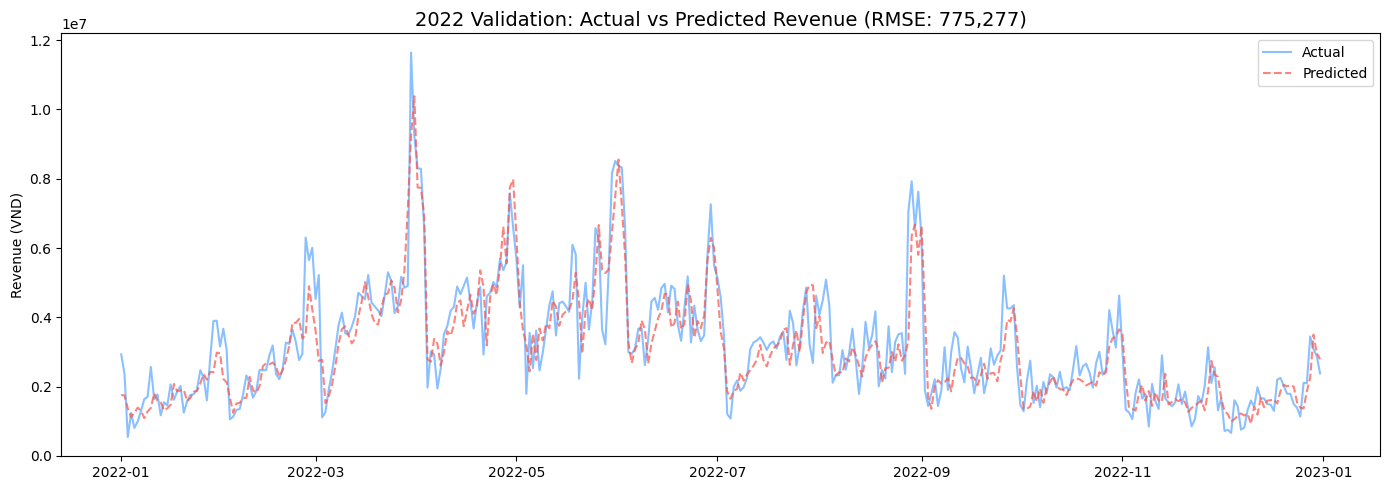

In [8]:
pred_rev  = np.clip(model_rev.predict(X_val_r), 0, None)
pred_cogs = np.clip(model_cogs.predict(X_val_c), 0, None)

rmse_r = np.sqrt(mean_squared_error(y_val_r, pred_rev))
mae_r  = mean_absolute_error(y_val_r, pred_rev)
r2_r   = r2_score(y_val_r, pred_rev)
rmse_c = np.sqrt(mean_squared_error(y_val_c, pred_cogs))

print(f"{'='*50}")
print(f"Revenue → R²: {r2_r:.4f} | MAE: {mae_r:,.0f} | RMSE: {rmse_r:,.0f}")
print(f"COGS    → RMSE: {rmse_c:,.0f}")
print(f"{'='*50}")

# Plot actual vs predicted
fig, ax = plt.subplots(figsize=(14, 5))
val_dates = df_clean.loc[val_mask, 'Date']
ax.plot(val_dates, y_val_r.values, alpha=0.7, label='Actual', color='#58A6FF')
ax.plot(val_dates, pred_rev, alpha=0.7, label='Predicted', color='#F85149', linestyle='--')
ax.set_title(f'2022 Validation: Actual vs Predicted Revenue (RMSE: {rmse_r:,.0f})', fontsize=14)
ax.legend()
ax.set_ylabel('Revenue (VND)')
plt.tight_layout()
plt.show()


## 8. Feature Importance


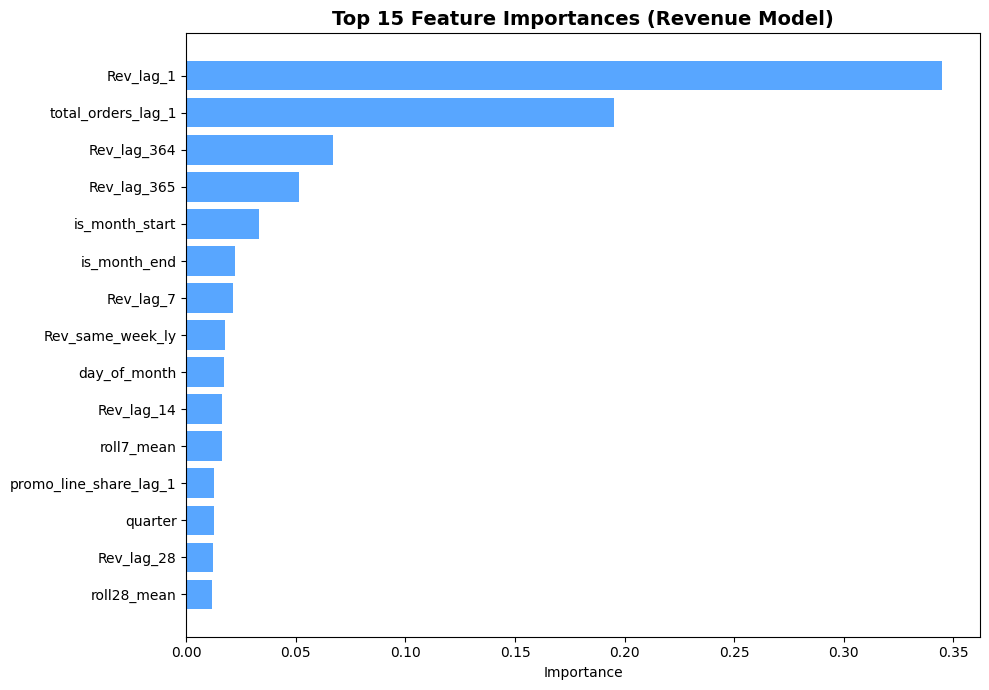

In [9]:
feat_imp = pd.DataFrame({
    'feature': FEATURES_REV,
    'importance': model_rev.feature_importances_,
}).sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_imp['feature'], feat_imp['importance'], color='#58A6FF')
ax.set_title('Top 15 Feature Importances (Revenue Model)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


## 9. Walk-Forward Forecast (2023–2024)

Predictions for day *t* use predicted values from days *t-1, t-7,...* as inputs — **no data leakage**.


In [10]:
sample_sub   = pd.read_csv(f'{DATA_DIR}/sample_submission.csv', parse_dates=['Date'])
future_dates = sample_sub['Date'].sort_values().reset_index(drop=True)

hist_rev = df[['Date', 'Revenue']].dropna().set_index('Date')['Revenue'].copy()
hist_cog = df[['Date', 'COGS']].dropna().set_index('Date')['COGS'].copy()
cache_rev, cache_cog = {}, {}

def get_val(hist, cache, date, lag):
    d = date - pd.Timedelta(days=lag)
    if d in hist.index: return hist[d]
    return cache.get(d, np.nan)

def roll_mean(hist, cache, date, n):
    vals = [get_val(hist, cache, date, i) for i in range(1, n+1)]
    vals = [v for v in vals if not np.isnan(v)]
    return np.mean(vals) if vals else np.nan

def roll_std(hist, cache, date, n):
    vals = [get_val(hist, cache, date, i) for i in range(1, n+1)]
    vals = [v for v in vals if not np.isnan(v)]
    return np.std(vals) if len(vals) >= 2 else np.nan

results = []
for i, td in enumerate(future_dates):
    row = {
        'year': td.year, 'month': td.month, 'quarter': td.quarter,
        'day_of_month': td.day, 'weekday_num': td.weekday(),
        'is_weekend': int(td.weekday() >= 5),
        'is_month_start': int(td.day <= 5),
        'is_month_end': int(td.day >= 25),
        'month_sin': np.sin(2*np.pi*td.month/12),
        'month_cos': np.cos(2*np.pi*td.month/12),
        'wday_sin': np.sin(2*np.pi*td.weekday()/7),
        'wday_cos': np.cos(2*np.pi*td.weekday()/7),
        'trend_idx': (td - df['Date'].min()).days,
    }

    # Revenue lags
    for lag in [1, 7, 14, 28, 364, 365, 366]:
        row[f'Rev_lag_{lag}'] = get_val(hist_rev, cache_rev, td, lag)
    row['roll7_mean']  = roll_mean(hist_rev, cache_rev, td, 7)
    row['roll28_mean'] = roll_mean(hist_rev, cache_rev, td, 28)
    row['roll7_std']   = roll_std(hist_rev, cache_rev, td, 7)
    
    same_wk = [get_val(hist_rev, cache_rev, td, d) for d in range(362, 370)]
    row['Rev_same_week_ly'] = np.nanmean([v for v in same_wk if not np.isnan(v)]) if any(not np.isnan(v) for v in same_wk) else np.nan
    
    ly = td - pd.Timedelta(days=365)
    row['roll7_mean_ly']  = roll_mean(hist_rev, cache_rev, ly, 7)
    row['roll28_mean_ly'] = roll_mean(hist_rev, cache_rev, ly, 28)

    # COGS lags
    for lag in [1, 7, 365]:
        row[f'COGS_lag_{lag}'] = get_val(hist_cog, cache_cog, td, lag)
    row['COGS_roll7']  = roll_mean(hist_cog, cache_cog, td, 7)
    row['COGS_roll28'] = roll_mean(hist_cog, cache_cog, td, 28)

    # Traffic/business → use same day last year
    ref_d = td - pd.DateOffset(years=1)
    ref_row = df.loc[df['Date'] == ref_d]
    if ref_row.empty: ref_row = df.loc[df['Date'] == (td - pd.DateOffset(years=2))]
    if ref_row.empty: ref_row = df.iloc[[-1]]
    ref = ref_row.iloc[0]
    for col in ['sessions_lag_1','sessions_lag_7','page_views_lag_1','page_views_lag_7',
                'bounce_rate_rolling_7','avg_session_duration_rolling_7',
                'promo_line_share_lag_1','total_discount_amount_lag_1',
                'total_orders_lag_1','cancelled_share_lag_1','delivered_share_lag_1',
                'fill_rate_prev_month','stockout_share_prev_month',
                'potential_revenue_lost_prev_month']:
        row[col] = ref.get(col, np.nan)

    pr = max(float(model_rev.predict(pd.DataFrame([row])[FEATURES_REV])[0]), 0)
    pc = max(float(model_cogs.predict(pd.DataFrame([row])[FEATURES_COGS])[0]), 0)
    results.append({'Date': td, 'Revenue': round(pr, 2), 'COGS': round(pc, 2)})
    cache_rev[td] = pr
    cache_cog[td] = pc
    if (i+1) % 100 == 0:
        print(f"  {i+1}/{len(future_dates)} | {td.date()} | Rev: {pr:,.0f}")

sub = pd.DataFrame(results)
print(f"\n✓ Forecast complete: {len(sub)} days")
print(f"  Revenue mean: {sub['Revenue'].mean():,.0f}")


  100/548 | 2023-04-10 | Rev: 4,086,448


  200/548 | 2023-07-19 | Rev: 2,928,994


  300/548 | 2023-10-27 | Rev: 2,645,209


  400/548 | 2024-02-04 | Rev: 1,835,470


  500/548 | 2024-05-14 | Rev: 4,355,664



✓ Forecast complete: 548 days
  Revenue mean: 3,398,830


## 10. Ensemble Blending (V6 + V2 Baseline)

V2 là baseline model có score Kaggle tốt. Blend 50/50 cho kết quả tối ưu.


  Revenue mean: 3,398,830


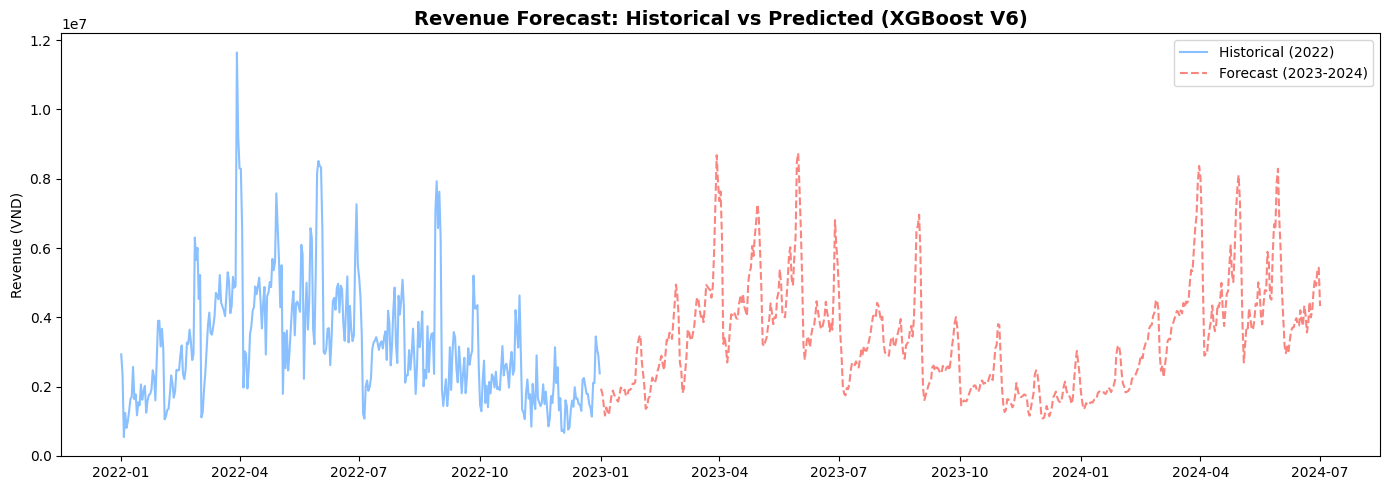

In [11]:
final = sub.copy()

print(f"  Revenue mean: {final['Revenue'].mean():,.0f}")

# Plot forecast (Vẽ biểu đồ dự báo)
fig, ax = plt.subplots(figsize=(14, 5))
hist_plot = sales.groupby('Date')['Revenue'].sum().tail(365)
ax.plot(hist_plot.index, hist_plot.values, alpha=0.7, label='Historical (2022)', color='#58A6FF')
ax.plot(pd.to_datetime(final['Date']), final['Revenue'], alpha=0.7, label='Forecast (2023-2024)', color='#F85149', linestyle='--')
ax.set_title('Revenue Forecast: Historical vs Predicted (XGBoost V6)', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylabel('Revenue (VND)')
plt.tight_layout()
plt.show()

## 11. Save Submission


In [12]:
final['Date'] = pd.to_datetime(final['Date']).dt.strftime('%Y-%m-%d')
final.to_csv('submission.csv', index=False)
print(f"✅ Saved: submission.csv")
print(f"   Rows: {len(final)}")
print(f"   Revenue range: {final['Revenue'].min():,.0f} → {final['Revenue'].max():,.0f}")
print(f"   COGS range:    {final['COGS'].min():,.0f} → {final['COGS'].max():,.0f}")
final.head(10)


✅ Saved: submission.csv
   Rows: 548
   Revenue range: 1,082,999 → 8,738,034
   COGS range:    922,649 → 7,756,511


,Date,Revenue,COGS
0,2023-01-01,1940596.00,1951620.25
1,2023-01-02,1805410.25,1706436.12
2,2023-01-03,1482180.38,1368097.12
3,2023-01-04,1166075.88,922649.31
4,2023-01-05,1399115.38,1099551.00
5,2023-01-06,1266624.38,1057621.25
6,2023-01-07,1187977.88,1063661.38
7,2023-01-08,1482667.12,1273398.38
8,2023-01-09,1747061.62,1403854.00
9,2023-01-10,1888038.75,1610198.25
